# Detecció d'opinions
La primera part de la pràctica 2 consisteix en la detecció d'opinions i la seva classificació com a positives o negatives. El primer pas ha estat importar les dades que s'utilitzaran com a corpus.



In [8]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr


[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Algoritmes d'aprenentatge supervisat

### Preparació de les dades

La primera part de la preparació de les dades consisteix a netejar-les. Aquest procés inclou tres passos principals:
Primer, normalitzem el text posant-lo tot en minúscules i eliminant qualsevol caràcter que no sigui una lletra de l'alfabet (a-z), com ara números, signes de puntuació o símbols especials. Això evita que el model tracti "genial!", "genial," i "genial" com tres paraules diferents.
Segon, lematitzem el text, és a dir, reduïm cada paraula a la seva forma base o lema. Per exemple, "running", "runs" i "ran" es converteixen totes en "run". Gràcies a això, el vocabulari és molt més compacte i el model pot aprendre millor les relacions entre paraules.
Tercer, eliminem les stopwords de l'anglès per quedar-nos només amb aquelles paraules que poden aportar significat i ajudar a la classificació de les opinions. Tot i això, s'ha tingut en compte que les opinions negatives sovint contenen expressions com "I don't like..." o "It's not a...", de manera que les negacions com "not", "don't" i "no" s'han conservat al text per tal de facilitar al model l'aprenentatge de patrons per distingir opinions positives i negatives.

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

#no treure les negacions, nomes les paraules amb significat -> dont, not

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text_string(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if (t not in stop_words and len(t) > 1) or (t == "not") or (t == "don't") or (t == "no")
    ]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


El corpus "movie_review" ja compta amb les etiquetes "pos" i "neg" per a opinions positives i negatives respectivament. Per preparar les dades, hem separat aquestes etiquetes i hem dividit el corpus en train i test, amb un 20% del corpus per al test i un 80% per a l'entrenament dels models.
A més, s'aplica la funció feta anteriorment, que deixa el text net per poder entrenar els models adequadament.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Separar les etiquetes ("pos" i "neg") que fan referència a la categoria
documents = []
labels = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text = mr.raw(fileid)                 
        clean_text = clean_text_string(raw_text)  

        if clean_text:                            
            documents.append(clean_text)
            labels.append(categoria)

# Si no fem això a vegades s'afageixen opinions buides i genera errors, 
# per tant, només si hi ha text s'afageix a les dades

# Divisió del corpus train/test

X_train, X_test, y_train, y_test = train_test_split(
    documents, labels, test_size=0.2, random_state=42
)


A continuació, com que les dades són strings, les convertim a números, ja que els models que hem escollit per classificar només funcionen amb valors numèrics. Per fer això, utilitzem CountVectorizer, que converteix el text en vectors numèrics.

Hem d'escollir l'hiperparàmetre max_features, que fa referència a la mida del vocabulari que utilitzarà el model. Per escollir-lo, cal tenir en compte que si és massa petit es perdrà molta informació, i si és massa gran augmentarà considerablement el cost computacional.

Tenim aprop de 40.000 paraules per tant hem escollit aquest possibles valors per l'hiperparàmetre: [100, 5000, 12000, 20000]


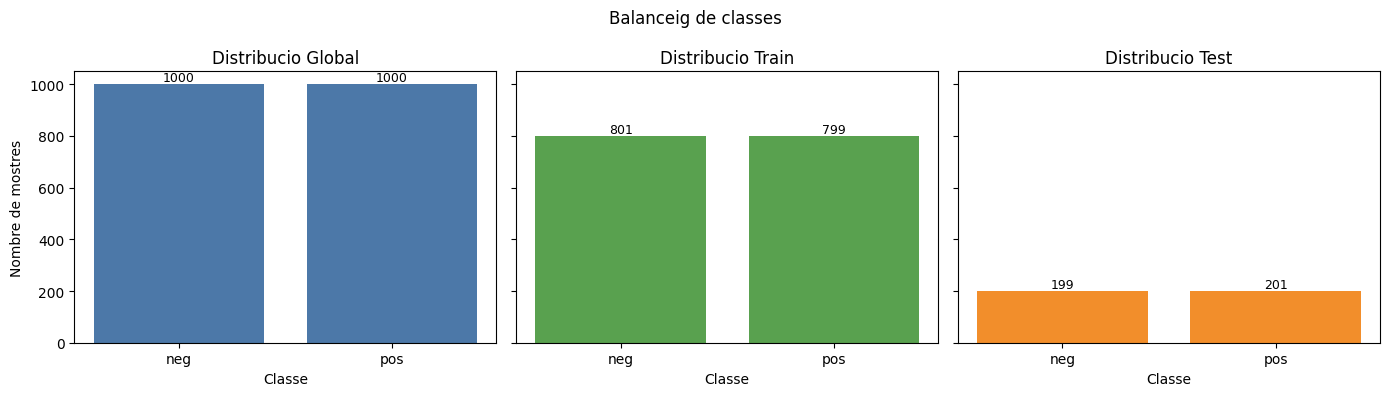

GLOBAL: {'neg': 1000, 'pos': 1000}
TRAIN: {'neg': 801, 'pos': 799}
TEST: {'pos': 201, 'neg': 199}


In [17]:
# Comprovacio de balanc de classes (global, train i test)
from collections import Counter
import matplotlib.pyplot as plt

global_counts = Counter(labels)
train_counts = Counter(y_train)
test_counts = Counter(y_test)

classes = sorted(global_counts.keys())
global_values = [global_counts.get(c, 0) for c in classes]
train_values = [train_counts.get(c, 0) for c in classes]
test_values = [test_counts.get(c, 0) for c in classes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

axes[0].bar(classes, global_values, color="#4C78A8")
axes[0].set_title("Distribucio Global")
axes[0].set_ylabel("Nombre de mostres")

axes[1].bar(classes, train_values, color="#59A14F")
axes[1].set_title("Distribucio Train")

axes[2].bar(classes, test_values, color="#F28E2B")
axes[2].set_title("Distribucio Test")

for ax, vals in zip(axes, [global_values, train_values, test_values]):
    for i, v in enumerate(vals):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("Classe")

plt.suptitle("Balanceig de classes")
plt.tight_layout()
plt.show()

print("GLOBAL:", dict(global_counts))
print("TRAIN:", dict(train_counts))
print("TEST:", dict(test_counts))

Per últim, hem observat gràficament el balanceig de les dues classes "pos" i "neg" de les nostres dades per descobrir si caldria realitzar alguna mètrica determinada o fins i tot generar algun pes en els models per tal d'obtenir models no esbiaixats.
En aquest cas tant les dades globals, com amb les que entrenen i fem el test es troben balancejades.

### SVM (Super Vector Machine)

Per entrenar el primer model escollit s'ha fet un GridSearch on s'avaluen diferents combinacions d'hiperparàmetres, tant del propi SVM, com ara el kernel i el paràmetre C, com del pas de vectorització, concretament el max_features. D'aquesta manera, s'escollirà el millor conjunt d'hiperparàmetres en funció de l'accuracy i altres mètriques i amb aquest conjunt òptim s'entrenarà el model final.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("svc", SVC())
])

param_grid = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__C": [0.001, 0.1, 1, 10],
    "svc__gamma": ["scale", "auto"]
}

# Cerca exhaustiva per validació creuada
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Millors paràmetres:", grid.best_params_)
print(f"Millor accuracy CV: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Millors paràmetres: {'svc__C': 10, 'svc__gamma': 'auto', 'svc__kernel': 'rbf', 'vect__max_features': 12000}
Millor accuracy CV: 0.8275

Accuracy test: 0.8125

Classification report:

              precision    recall  f1-score   support

         neg       0.80      0.84      0.82       199
         pos       0.83      0.79      0.81       201

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400




Després de realitzar l'experimentació mitjançant Cross-Validation de 5 folds, avaluant 96 combinacions d'hiperparàmetres, el millor conjunt trobat per al SVM és el següent: una C de 10, un gamma de auto, un kernel de tipus rbf i un max_features de 12.000.

Amb aquest conjunt d'hiperparàmetres s'obté un accuracy sobre el test de 0.8125. Per confirmar que el model generalitza correctament, també s'analitzen la precisió, el recall i el F1-score, on s'observa que el model no està esbiaixat cap a cap de les dues classes.

### XGBoost

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# XGBoost requereix classes numèriques (0/1)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("xgb", XGBClassifier(eval_metric="logloss", verbosity=0))
])

param_grid = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "xgb__n_estimators": [50, 100, 300],
    "xgb__max_depth": [3, 6, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train_enc)

print("Millors paràmetres:", grid.best_params_)
print(f"Millor accuracy CV: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_enc = best_model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_enc)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Millors paràmetres: {'vect__max_features': 12000, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 300}
Millor accuracy CV: 0.8119

Accuracy test: 0.8500

Classification report:

              precision    recall  f1-score   support

         neg       0.83      0.87      0.85       199
         pos       0.87      0.83      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



Pel que fa a XGBoost, s'han avaluat 108 combinacions diferents mitjançant Cross-Validation de 5 folds. El millor conjunt d'hiperparàmetres obtingut és el següent: un max_features de 12.000, un learning_rate de 0.05, un max_depth de 3 i un n_estimators de 300.
En aquest cas, l'accuracy obtinguda en el test és superior a la del SVM. Igual que abans, s'analitzen la precisió, el recall i el F1-score per verificar que el model ha après patrons de manera equilibrada i no afavoreix cap de les dues classes.



### Regressió Logística

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("logreg", LogisticRegression(max_iter=3000))
])

# Grid de paràmetres per a Regressió Logística
param_grid = [
    {
        "vect__max_features": [100, 5000, 12000, 20000],
        "logreg__penalty": ["l1", "l2"],
        "logreg__C": [0.01, 0.1, 1, 10]
    }
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Millors paràmetres:", grid.best_params_)
print(f"Millor accuracy CV: {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

NameError: name 'X_train' is not defined

Per últim, s'ha emprat una regressió logística on s'han explorat diferents regularitzacions i valors del paràmetre max_features del CountVectorizer. En aquest cas, el conjunt d'hiperparàmetres amb millors mètriques és el següent: una C de 0.01, una regularització de tipus l2 i un max_features de 5.000, obtenint un accuracy en el test de 0.83.

## Protocol de Validació Models Finals

En aquest apartat s'avaluaran els 3 models finals amb els hiperparàmetres obtinguts en la fase d'experimentació. Per fer-ho, s'aplicarà un protocol de validació que inclou tres anàlisis complementàries: la matriu de confusió, per identificar quins tipus d'errors comet cada model; la corba ROC, per mesurar la qualitat global del classificador; i l'anàlisi dels exemples mal classificats, per entendre en quins casos concrets falla cada model.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("COMPARACIO FINAL: SVM vs REGRESSIO LOGISTICA vs XGBOOST")

# 1) Entrenament dels 3 models finals
print("\n1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...")
final_svm = Pipeline([
    ("vect", CountVectorizer(max_features=12000)),
    ("svc", SVC(C=10, kernel="rbf", gamma="auto"))
])
final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)

print("2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...")
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
xgb_unigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 1))),
    ("xgb", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        eval_metric="logloss",
        verbosity=0
    ))
])
xgb_unigram.fit(X_train, y_train_enc)
y_pred_unigram_enc = xgb_unigram.predict(X_test)
y_pred_unigram = label_encoder.inverse_transform(y_pred_unigram_enc)

print("3. Entrenant model final de Regressio Logistica (max_features=5000, C=0.01, penalty=l2)")
final_rl = Pipeline([
    ("vect", CountVectorizer(max_features=5000)),
    ("logreg", LogisticRegression(C=0.01, penalty="l2", solver="lbfgs", max_iter=3000))
])
final_rl.fit(X_train, y_train)
y_pred_rl = final_rl.predict(X_test)

# Variables comunes i contenidor de resultats
y_test_arr = np.array(y_test)
y_test_bin = (y_test_arr == "pos").astype(int)
results_summary = []

def valida_i_mostra(model_name, model, y_pred):
    print("\n" + "=" * 90)
    print(f"MODEL: {model_name}")
    print("=" * 90)

    # Metriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)

    print("\nMETRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    results_summary.append({
        "Model": model_name.split("(")[0].strip(),
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

    # Matriu de confusio
    print("\nMATRIU DE CONFUSIO:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Prediccio Neg  Prediccio Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriu de Confusio - {model_name.split('(')[0].strip()}")
    plt.tight_layout()
    plt.show()

    # Corba ROC-AUC
    print("\nCORBA ROC-AUC:")
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            y_proba = model.predict(X_test).astype(float)

        fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
        roc_auc = auc(fpr, tpr)
        print(f"  AUC Score: {roc_auc:.4f}")

        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC={roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Corba ROC - {model_name.split('(')[0].strip()}")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Error calculant ROC: {e}")

    # Errors
    print("\nANALISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate * 100:.2f}%)")

COMPARACIO FINAL: SVM vs REGRESSIO LOGISTICA vs XGBOOST

1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...
2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...
3. Entrenant model final de Regressio Logistica (max_features=5000, C=0.01, penalty=l2)



MODEL: SVM (RBF, C=10, max_features=12000)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8175
  Precision: 0.8299
  Recall:    0.8010
  F1-Score:  0.8152

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          166             33
  Real Pos:           40            161


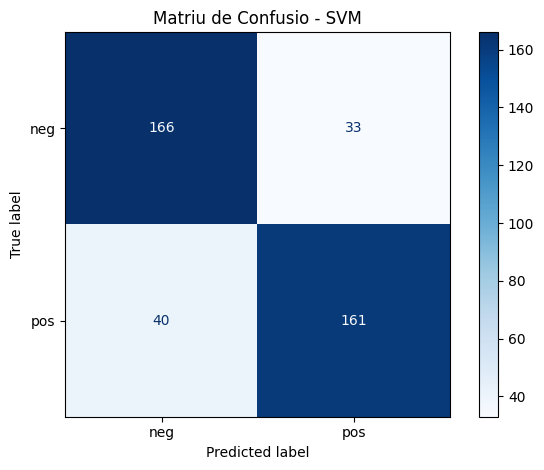


CORBA ROC-AUC:
  AUC Score: 0.8879


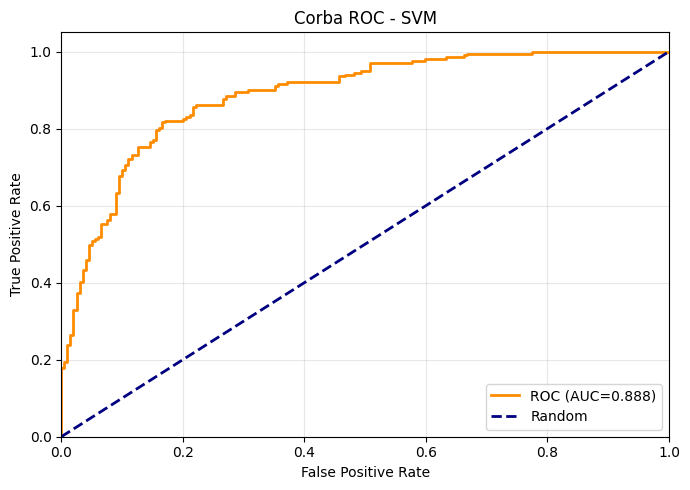


ANALISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)


In [12]:
# Validacio SVM
valida_i_mostra(
    "SVM (RBF, C=10, max_features=12000)",
    final_svm,
    y_pred_svm
)

## Anàlisis SVM

Gràcies a la matriu de confusió podem observar que, a més d'obtenir un bon accuracy, el model no prioritza cap de les dues classes, cosa que és senyal d'un bon aprenentatge equilibrat, malgrat hi hagi alguns FN més que FP. Malgrat això, ha comès alguns errors que, analitzant-los, ens permeten deduir quins són els principals problemes del model a l'hora de classificar.

Pel que fa a la corba ROC, s'obté un AUC de 0.8879, la qual cosa indica que es tracta d'un classificador de bona qualitat.
Quant als errors, se n'han identificat quatre causes principals:

La primera és el pes enganyós de certes paraules. El model associa paraules com "successful", "happy" o "never" a una classe concreta, quan en realitat el seu sentiment depèn del context. Per exemple, a l'error 3, la paraula "successful" apareix dues vegades en una ressenya negativa i fa que el model la classifiqui com a positiva. De manera similar, a l'error 34, la paraula "happy" indueix el model a error en una ressenya positiva, i a l'error 6, "never" fa que una ressenya positiva es classifiqui com a negativa.

La segona causa són la ironia i el sarcasme. El model no és capaç d'entendre el context global d'una frase. A l'error 14, la ressenya descriu "battlefield earth" com el pitjor film de l'any, però paraules com "guarantee" fan que el model la classifiqui com a positiva. De manera semblant, a l'error 21, el crític valora positivament "evil dead ii" precisament pels seus defectes, "bad movie", "terrible acting", cosa que el model és incapaç de capturar.

La tercera causa és el vocabulari temàtic enganyós. Certes paraules estan tan associades a un sentiment concret dins del corpus que el model les utilitza com a indicadors independentment del context. Als errors 29 i 49, la paraula "Disney" apareix en ressenyes negatives, però com que en el corpus majoritàriament apareix en ressenyes positives, el model la classifica erròniament com a positiva.

La quarta causa són les ressenyes amb estructura mixta. Algunes ressenyes comencen elogiant aspectes de la pel·lícula i acaben criticant-la, o a l'inrevés. A l'error 5, la ressenya comença amb "steve martin one funniest men alive" però conclou que la pel·lícula és una decepció. El model es queda amb el sentiment predominant de les primeres paraules i no és capaç de capturar el gir negatiu final.

Malgrat això compta amb un Accuracy de 0.8175.



MODEL: Regressio Logistica (C=0.01, penalty=l2, max_features=5000)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8175
  Precision: 0.8232
  Recall:    0.8109
  F1-Score:  0.8170

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          164             35
  Real Pos:           38            163


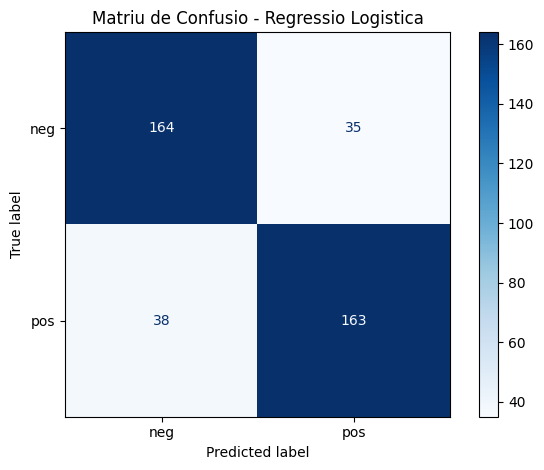


CORBA ROC-AUC:
  AUC Score: 0.8936


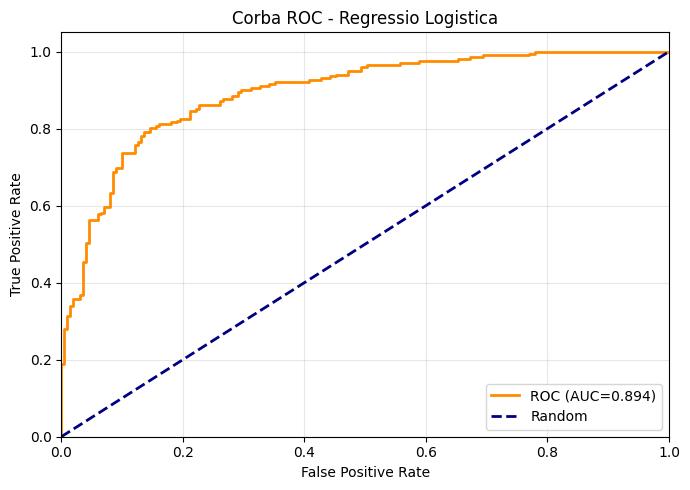


ANALISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)


In [13]:
# Validacio Regressio Logistica
valida_i_mostra(
    "Regressio Logistica (C=0.01, penalty=l2, max_features=5000)",
    final_rl,
    y_pred_rl
)

## Anàlisis Regressió Logística

Pel que fa a la Regressió Logística, la matriu de confusió mostra una diferència molt petita entre els falsos positius i els falsos negatius, cosa que indica que el model és encara més equilibrat que el SVM i no tendeix cap a cap classe majoritària. Quant a la corba ROC, s'obté un AUC de 0.8936, lleugerament superior al del SVM, la qual cosa suggereix una millor capacitat d'aprenentatge de patrons. L'accuracy assolida és de 0.8175, amb resultats també en el rang de 0.8-0.9 per a la resta de mètriques com el F1-score i el recall. A continuació s'analitzen alguns dels errors comesos per entendre quines situacions generen una classificació incorrecta.

En el cas de la Regressió Logística, els errors comesos segueixen una línia semblant als del model anterior, encara que amb algunes particularitats pròpies.

Un primer bloc d'errors s'explica per la càrrega semàntica individual de certes paraules. El model aprèn a associar determinades paraules a una classe concreta, però aquest aprenentatge falla quan apareixen en un context diferent. A l'error 65, el terme "successful" apareix en una ressenya negativa sobre Woody Allen i confon el model. De manera similar, a l'error 63, la mateixa paraula torna a aparèixer en una ressenya clarament negativa, on es descriu una pel·lícula com a candidata al pitjor film de l'any.

Un segon bloc d'errors prové de la incapacitat del model per detectar ironia i sarcasme. A l'error 66, la ressenya descriu "Armageddon" com una pel·lícula que "symbolizes everything wrong modern filmmaking", però altres paraules del text fan decantar el model cap a la classe negativa quan en realitat és positiva. L'error 52 és també representatiu: el crític descriu un blockbuster amb "bad script" i malgrat això la ressenya és positiva, ja que valora favorablement altres aspectes de la pel·lícula.

Un tercer bloc respon al biaix introduït per noms propis i marques. Als errors 53 i 58, la presència de termes associats a gèneres o estudis concrets porta el model a classificar incorrectament. A l'error 72, el nom "Terrence Malick" actua com a indicador positiu espuri en una ressenya negativa, atès que aquest director apareix habitualment lligat a valoracions positives dins el corpus.

Finalment, un quart bloc d'errors correspon a ressenyes amb un arc narratiu contradictori. A l'error 57, la ressenya comença descrivint una experiència prèvia positiva abans de girar cap a una valoració negativa de la pel·lícula en qüestió. A l'error 70, el crític reconeix aspectes positius al principi del text abans de concloure amb una valoració negativa, cosa que fa que el model es quedi amb el sentiment dominant de les primeres paraules i no processi el canvi de to posterior.

Aquests patrons coincideixen en gran mesura amb els observats al SVM.
  


MODEL: XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8375
  Precision: 0.8542
  Recall:    0.8159
  F1-Score:  0.8346

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          171             28
  Real Pos:           37            164


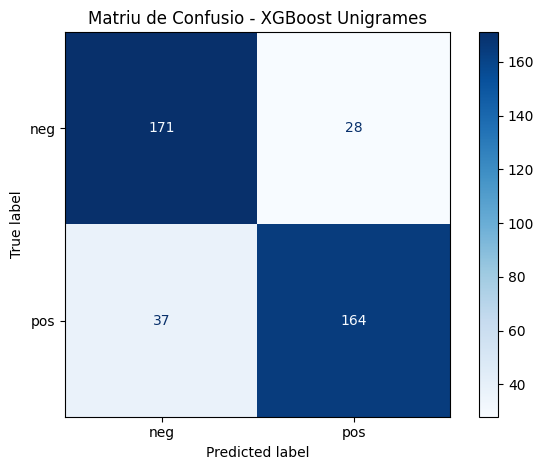


CORBA ROC-AUC:
  AUC Score: 0.9037


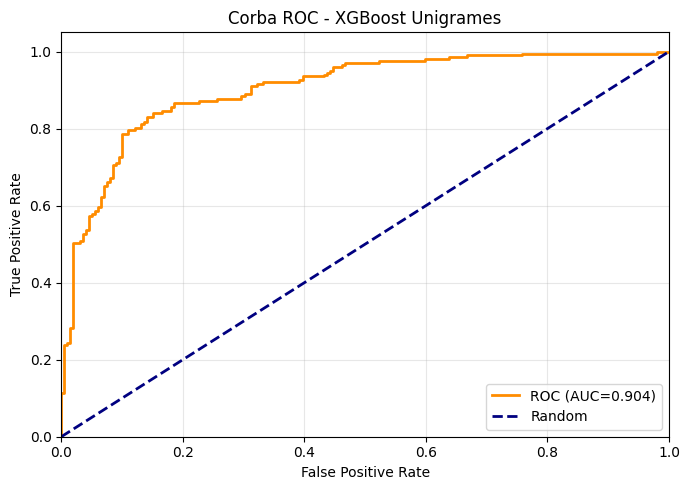


ANALISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)


In [15]:
# Validacio XGBoost
valida_i_mostra(
    "XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)",
    xgb_unigram,
    y_pred_unigram
)

## Anàlisis XGBoost


El XGBoost és el model que ofereix els millors resultats globals. La matriu de confusió reflecteix el nombre més baix de classificacions incorrectes dels tres models, i la corba ROC assoleix el valor d'AUC més alt (0.9037). Les mètriques obtingudes sobre el conjunt de test són les següents: un accuracy de 0.8375, una precisió de 0.8542, un recall de 0.8159 i un F1-score de 0.8346. Cal remarcar que el recall és lleugerament inferior a la precisió, tot i que la diferència és poc rellevant i no compromet la qualitat del model.

Malgrat el bon rendiment general, el model comet errors que es poden agrupar en diverses categories.

La primera categoria agrupa els errors causats pel pes de determinades paraules fora de context. El model ha après que certes expressions estan lligades a un sentiment concret, però aquest aprenentatge es trenca quan les mateixes paraules apareixen en un context diferent. A l'error 4, la frase "steve martin one funniest men alive" provoca que el model prevegi un sentiment positiu quan la ressenya és en realitat una crítica negativa a la pel·lícula. A l'error 54, el qualificatiu "successful" aplicat a Woody Allen orienta erròniament el model cap a la classe positiva, malgrat que la ressenya qüestiona la seva trajectòria recent.

La segona categoria recull els errors vinculats a la detecció d'ironia i sarcasme. A l'error 15, expressions com "bad movie", "terrible acting" i "pointless violence" haurien d'indicar un sentiment clarament negatiu, però la ressenya és positiva perquè l'autor considera "Evil Dead II" una obra de culte que val la pena precisament pels seus excessos. A l'error 55, la ressenya critica "Armageddon" com a símbol dels mals del cinema contemporani, però el model no és capaç de llegir el to irònic i la classifica incorrectament.

La tercera categoria engloba els errors provocats pel valor dels noms propis. Tant als errors 31 i 37, la paraula "Disney" apareix en ressenyes negatives, però com que al corpus aquesta marca sol anar acompanyada de valoracions positives, el model la interpreta com un senyal favorable. A l'error 61, el nom "Terrence Malick" genera el mateix efecte: el model associa automàticament aquest director a crítiques positives i falla quan la ressenya és negativa. O el biaix per referències a la cultura popular. A l'error 63, mencions a les Spice Girls i a productes d'entreteniment massius confonen el model. A l'error 2, referències a Mark Wahlberg i a "Boogie Nights", figures amb a un cert prestigi, fan inclinar la predicció cap al sentiment positiu en una ressenya que en realitat és negativa.

La quarta categoria recull els errors deguts a ressenyes contradictories. A l'error 22, el crític comença reconeixent el potencial de la pel·lícula i només al final revela que el resultat és decebedor. A l'error 46, la ressenya s'inicia recordant una experiència cinematogràfica prèvia agradable, però acaba criticant durament la pel·lícula analitzada. En ambdós casos, el model es queda ancorat en el to positiu de l'inici i no detecta el gir negatiu posterior.


En definitiva, tot i que el XGBoost supera els altres dos models en totes les mètriques, els tipus d'errors que comet són essencialment els mateixos. Això confirma que el sostre de rendiment d'aquests models no ve determinat per l'algorisme escollit, sinó per la manera com es representa el text: el CountVectorizer tracta cada paraula com una unitat independent, sense tenir en compte l'ordre, el context ni les relacions semàntiques entre paraules.

In [16]:
# Taula resum comparativa
print("\n" + "=" * 90)
print("TAULA RESUM COMPARATIVA")
print("=" * 90)

df_results = pd.DataFrame(results_summary)
print("\n" + df_results.to_string(index=False))


TAULA RESUM COMPARATIVA

              Model Accuracy Precision Recall F1-Score
                SVM   0.8175    0.8299 0.8010   0.8152
Regressio Logistica   0.8175    0.8232 0.8109   0.8170
  XGBoost Unigrames   0.8375    0.8542 0.8159   0.8346


## Conclusions 

Després d'analitzar els tres models i comprovar que els seus errors de classificació responen a patrons similars, s'ha decidit escollir el XGBoost com a model final, ja que és el que obté els millors resultats en totes les mètriques avaluades.

## MODEL FINAL

Un cop escollit el model final, i havent identificat algunes de les causes dels errors, s'analitzarà si l'ús de bigrames en lloc d'unigrames pot millorar la capacitat predictiva del model, ja que permeten capturar relacions més complexes entre paraules, com ara "don't like". D'aquesta manera es podrà determinar si aquest canvi és suficient per millorar el rendiment o si calen modificacions més profundes.

COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames

MODEL: XGBoost Unigrames

MÈTRIQUES DE RENDIMENT:
  Accuracy:  0.8375
  Precision: 0.8542
  Recall:    0.8159
  F1-Score:  0.8346

MATRIU DE CONFUSIÓ:
                  Predicció Neg  Predicció Pos
  Real Neg:          171             28
  Real Pos:           37            164


<Figure size 700x500 with 0 Axes>

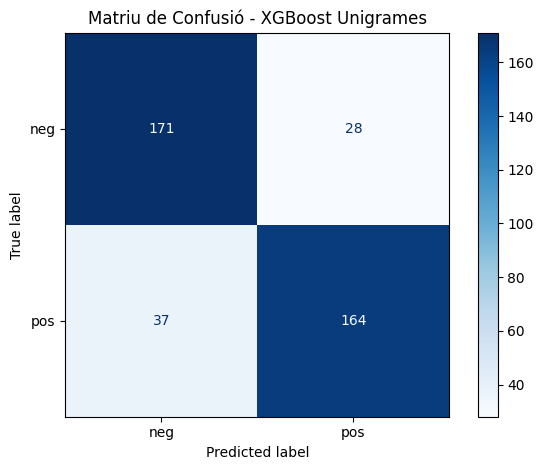


ANÀLISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: pos → Predicció: neg
    Text: 'company men made splash sundance film festival year plagued brother mcmullen style earnestly shallow...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 2:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

<Figure size 700x500 with 0 Axes>

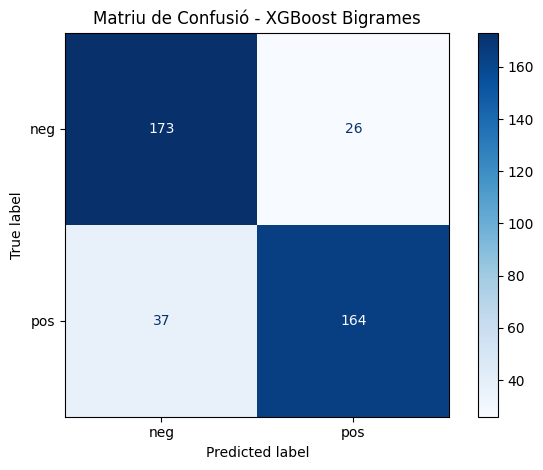


ANÀLISI D'ERRORS:
  Nombre d'errors: 63 / 400
  Taxa d'errors: 0.1575 (15.75%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 2:
    Real: pos → Predicció: neg
    Text: 'vampire lore legend always popular fantasy element substantiated not sheer number movie subject also...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

print("="*90)
print("COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames")

# 1. ENTRENAR MODEL FINAL DE XGBOOST AMB BIGRAMES

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_bigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 2))),
    ("xgb", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, 
                          eval_metric="logloss", verbosity=0))
])

xgb_bigram.fit(X_train, y_train_enc)
y_pred_bigram_enc = xgb_bigram.predict(X_test)
y_pred_bigram = label_encoder.inverse_transform(y_pred_bigram_enc)

# 2. COMPARACIÓ DELS DOS MODELS
y_test_arr = np.array(y_test)

models_xgb = {
    "XGBoost Unigrames": {
        "model": xgb_unigram,
        "predictions": y_pred_unigram
    },
    "XGBoost Bigrames": {
        "model": xgb_bigram,
        "predictions": y_pred_bigram
    }
}

results = []

for model_name, model_info in models_xgb.items():
    model = model_info["model"]
    y_pred = model_info["predictions"]
    
    print("\n" + "="*90)
    print(f"MODEL: {model_name}")
    print("="*90)
    
    # MÈTRIQUES
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)
    
    print(f"\nMÈTRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    results.append({
        "Model": model_name,
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })
    
    # MATRIU DE CONFUSIÓ
    print(f"\nMATRIU DE CONFUSIÓ:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Predicció Neg  Predicció Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")
    
    # GRÀFIC MATRIU DE CONFUSIÓ
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    plt.figure(figsize=(7, 5))
    disp.plot(cmap='Blues')
    plt.title(f"Matriu de Confusió - {model_name}")
    plt.tight_layout()
    plt.show()
    
    # ERRORS I EXEMPLES MAL CLASSIFICATS
    print(f"\nANÀLISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    if num_errors > 0:
        print(f"\n  EXEMPLES MAL CLASSIFICATS:")
        error_indices = np.where(errors_mask)[0]
        
        for i, idx in enumerate(error_indices):
            actual = y_test_arr[idx]
            predicted = y_pred[idx]
            text_preview = X_test[idx][:100] + "..." if len(X_test[idx]) > 100 else X_test[idx]
            
            print(f"\n  Error {i}:")
            print(f"    Real: {actual} → Predicció: {predicted}")
            print(f"    Text: '{text_preview}'")

# 3. TAULA RESUM COMPARATIVA
print("\n" + "="*90)
print("TAULA RESUM COMPARATIVA")
print("="*90)

df_xgb = pd.DataFrame(results)
print("\n" + df_xgb.to_string(index=False))

print("\n" + "="*90)
print("CONCLUSIÓ")
print("="*90)

f1_unigram = float(results[0]["F1-Score"])
f1_bigram = float(results[1]["F1-Score"])



## Conclusió Model Final

Comparant els dos models, el que utilitza bigrames obté millors resultats tant en la matriu de confusió com en l'accuracy i, per tant, en la taxa d'errors. Analitzant els errors de tots dos, es poden extreure les conclusions següents sobre l'aportació dels bigrames respecte als unigrames.

El model amb unigrames comet 65 errors, mentre que el model amb bigrames en comet 63. La reducció és molt petita, cosa que indica que els bigrames aporten una millora marginal però no substancial.

Pel que fa als errors que els bigrames han aconseguit resoldre, s'observa que alguns casos que els unigrames classificaven incorrectament desapareixen amb l'ús de parelles de paraules. Per exemple, l'error 14 dels unigrames "evil dead ii bad movie full terrible acting pointless violence"  es classifica correctament amb bigrames, probablement perquè combinacions com "bad movie" o "terrible acting" aporten més context que les paraules aïllades. De manera similar, l'error 43 "bowfinger good movie making bad one" també es resol, ja que parelles com "good movie" i "bad one" ajuden a calibrar millor el sentiment global.

Malgrat això, la gran majoria d'errors es repeteixen en els dos models. Casos com "steve martin one funniest men alive" (error 3 en tots dos), "Woody Allen successful" (errors 53 i 51), "Terrence Malick" (errors 60 i 59) o les Spice Girls (errors 62 i 61) apareixen en ambdues llistes sense variació. Això posa de manifest que els bigrames no resolen els problemes estructurals del model: el biaix introduït per noms propis, la ironia i les ressenyes amb un arc narratiu contradictori continuen sent fonts d'error independentment del tipus de n-grama utilitzat.

A més, els bigrames introdueixen alguns errors nous que els unigrames no cometien, com ara l'error 2 "vampire lore legend always popular fantasy" , l'error 24 "rushmore"  o l'error 44 "razor blade smile". Això suggereix que en determinats casos els bigrames sobreajusten el model a combinacions de paraules molt concretes que no generalitzen bé a exemples nous.

En conclusió, tot i que els bigrames aporten una millora lleugera, no resolen les limitacions fonamentals del model. Per obtenir un increment significatiu del rendiment caldria un enfocament diferent, basat en representacions semàntiques més riques i robustes que tinguin en compte el context global de cada ressenya.

# MODEL SUPERVISAT


Com a apartat addicional, aplicarem WSD mitjançant l'algorisme Lesk per enriquir els textos 
amb informació semàntica, i entrenarem un model kNN sobre aquestes dades enriquides. 
Els resultats s'compararan amb els d'un kNN entrenat sense WSD, per avaluar si 
la desambiguació semàntica aporta una millora real al model.

El procediment consisteix a identificar les paraules freqüents al corpus que presenten 
més d'un sentit a WordNet, i desambiguar-les mitjançant Lesk. A continuació, 
s'entrena el model kNN sobre els textos enriquits i s'analitzen els resultats obtinguts.


In [ ]:
# WSD + kNN per a detecció d'opinions
# Reutilitza X_train, X_test, y_train, y_test generats anteriorment

import nltk
import numpy as np
from collections import Counter
from functools import lru_cache
from nltk.wsd import lesk
from nltk.corpus import wordnet as wn
from nltk import word_tokenize, pos_tag
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Recursos necessaris de NLTK
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Construcció automàtica de paraules ambigües des del train
# Criteri: freqüents al corpus i amb més d'un sentit a WordNet
WSD_SCAN_DOCS = 1200
WSD_MIN_FREQ = 20
WSD_MAX_TARGETS = 200

token_counts = Counter()
for text in X_train[:WSD_SCAN_DOCS]:
    token_counts.update(
        tok.lower()
        for tok in word_tokenize(text)
        if tok.isalpha() and len(tok) > 2
    )

candidate_targets = [
    tok for tok, freq in token_counts.items()
    if freq >= WSD_MIN_FREQ and len(wn.synsets(tok)) > 1
]

candidate_targets.sort(key=lambda w: token_counts[w], reverse=True)
AMBIGUOUS_TARGETS = set(candidate_targets[:WSD_MAX_TARGETS])

print(f"AMBIGUOUS_TARGETS extrets automàticament: {len(AMBIGUOUS_TARGETS)}")
print("Mostra:", sorted(list(AMBIGUOUS_TARGETS))[:10000])


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ashve\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


AMBIGUOUS_TARGETS extrets automàticament: 200
Mostra: ['acting', 'action', 'actor', 'actually', 'alien', 'along', 'always', 'american', 'around', 'attempt', 'audience', 'away', 'back', 'bad', 'become', 'becomes', 'begin', 'best', 'better', 'big', 'bit', 'black', 'boy', 'brother', 'cast', 'character', 'child', 'come', 'comedy', 'completely', 'couple', 'course', 'day', 'death', 'dialogue', 'director', 'done', 'effect', 'end', 'ending', 'enough', 'especially', 'even', 'ever', 'every', 'evil', 'eye', 'face', 'fact', 'fall', 'family', 'far', 'father', 'feel', 'film', 'find', 'first', 'friend', 'fun', 'funny', 'get', 'girl', 'give', 'given', 'going', 'good', 'got', 'great', 'guy', 'half', 'hand', 'hard', 'head', 'help', 'high', 'hollywood', 'home', 'horror', 'hour', 'however', 'human', 'humor', 'idea', 'instead', 'interesting', 'job', 'john', 'keep', 'kid', 'kind', 'know', 'last', 'laugh', 'lead', 'least', 'let', 'life', 'like', 'line', 'little', 'long', 'look', 'looking', 'lot', 'love', 'ma

Per realitzar el WSD amb Lesk, primer hem definit quines paraules del corpus són ambigües, 
és a dir, aquelles que tenen més d'un sentit a WordNet. Per a cada una d'aquestes paraules, 
apliquem l'algorisme Lesk dins del seu context per determinar quin sentit és el més adequat. 
Un cop desambiguada, afegim al text un token especial que representa el sentit trobat, de manera que el model de classificació posterior, 
en aquest cas el kNN, disposi d'informació semàntica addicional per millorar les seves prediccions. 
A més, per optimitzar el rendiment del procés, hem utilitzat una memòria cau (cache) 
que evita recalcular el sentit d'un mateix token en un mateix context més d'una vegada.

In [22]:
# Utilitzarem aquelles categories que poden tenir més 1 significat
def to_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wn.ADJ
    if treebank_tag.startswith('V'):
        return wn.VERB
    if treebank_tag.startswith('N'):
        return wn.NOUN
    if treebank_tag.startswith('R'):
        return wn.ADV
    return None


@lru_cache(maxsize=10000)
def disambiguate_token(context_tuple, token, wn_pos):
    context = list(context_tuple)
    return lesk(context, token, pos=wn_pos)


def wsd_enrich_text(text):
    tokens = [t for t in word_tokenize(text) if t.isalpha()]
    tagged = pos_tag(tokens)
    context_tuple = tuple(tokens)

    enriched = []
    for tok, tb_pos in tagged:
        low = tok.lower()
        enriched.append(low)

        if low not in AMBIGUOUS_TARGETS:
            continue

        wn_pos = to_wordnet_pos(tb_pos)
        if wn_pos is None:
            continue

        syn = disambiguate_token(context_tuple, low, wn_pos)
        if syn is not None:
            # Afegim un token de sentit per donar context semàntic al model
            enriched.append(f"sense_{syn.name().replace('.', '_')}")

    return ' '.join(enriched)



Un cop definida la funció d'enriquiment, l'apliquem sobre tot el corpus: tant el conjunt 
d'entrenament com el de test es processen amb `wsd_enrich_text`, obtenint dues noves llistes 
de textos enriquits amb la informació semàntica extreta per Lesk. Les etiquetes de classe 
no es veuen alterades, ja que el WSD només modifica la representació textual de les mostres. 

In [ ]:
# WSD sobre tot el corpus (sense limitació de mostres)
X_train_wsd = [wsd_enrich_text(t) for t in X_train]
X_test_wsd = [wsd_enrich_text(t) for t in X_test]
y_train_wsd = y_train
y_test_wsd = y_test


Train WSD: 1600 docs
Test WSD: 400 docs


Un cop enriquits els textos, s'ha entrenat un model kNN.
Per trobar els millors hiperparàmetres, s'ha aplicat una cerca en graella amb validació creuada 
de 5 folds sobre les combinacions de nombre de veïns i mida del vocabulari, obtenint com a 
millors paràmetres `n_neighbors=3` i `max_features=5000`, amb un F1-macro de 0.52 en validació.

Fitting 5 folds for each of 16 candidates, totalling 80 fits

MILLORS PARÀMETRES WSD + kNN
{'knn__n_neighbors': 3, 'vect__max_features': 5000}
Best CV f1_macro: 0.5234

RESULTATS TEST WSD + kNN
Accuracy: 0.5825

Classification report:

              precision    recall  f1-score   support

         neg     0.5519    0.8543    0.6706       199
         pos     0.6848    0.3134    0.4300       201

    accuracy                         0.5825       400
   macro avg     0.6184    0.5839    0.5503       400
weighted avg     0.6187    0.5825    0.5497       400



<Figure size 600x500 with 0 Axes>

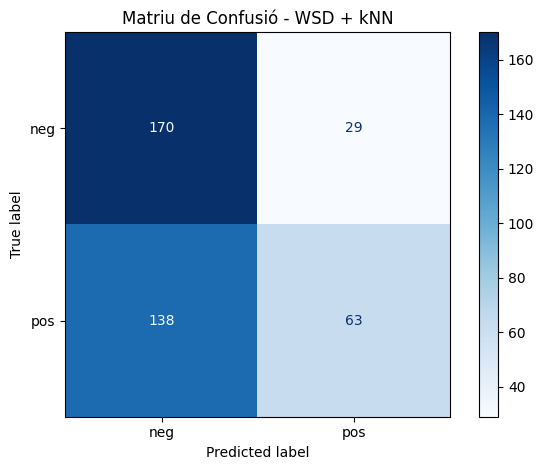

In [24]:
# Canviat a CountVectorizer + cerca de max_features al GridSearch
from sklearn.feature_extraction.text import CountVectorizer

pipe_wsd_knn = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ('knn', KNeighborsClassifier())
])

param_grid_wsd_knn = {
    'vect__max_features': [5000, 12000, 15000, 20000],
    'knn__n_neighbors': [3, 5, 7, 11]
}

grid_wsd_knn = GridSearchCV(
    estimator=pipe_wsd_knn,
    param_grid=param_grid_wsd_knn,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_wsd_knn.fit(X_train_wsd, y_train_wsd)

best_wsd_knn = grid_wsd_knn.best_estimator_
y_pred_wsd_knn = best_wsd_knn.predict(X_test_wsd)

print('\n' + '=' * 80)
print('MILLORS PARÀMETRES WSD + kNN')
print('=' * 80)
print(grid_wsd_knn.best_params_)
print(f"Best CV f1_macro: {grid_wsd_knn.best_score_:.4f}")

print('\n' + '=' * 80)
print('RESULTATS TEST WSD + kNN')
print('=' * 80)
print(f"Accuracy: {accuracy_score(y_test_wsd, y_pred_wsd_knn):.4f}")
print('\nClassification report:\n')
print(classification_report(y_test_wsd, y_pred_wsd_knn, digits=4))

cm = confusion_matrix(y_test_wsd, y_pred_wsd_knn, labels=['neg', 'pos'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg', 'pos'])
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues')
plt.title('Matriu de Confusió - WSD + kNN')
plt.tight_layout()
plt.show()


Els resultats sobre el conjunt de test han estat: una accuracy del 58.25% i un 
F1-macro de 0.55. Analitzant el report de classificació, s'observa un desequilibri notable 
entre les dues classes: la classe *neg* obté un recall molt alt (0.85) però una precisió baixa 
(0.55), mentre que la classe *pos* presenta el patró invers, amb una precisió acceptable (0.68) 
però un recall molt baix (0.31). Això indica que el model tendeix a classificar la majoria de 
mostres com a negatives.

La matriu de confusió confirma el desequilibri observat en el 
classification report. El model classifica correctament 170 de les 199 mostres negatives 
(un recall del 85%), però només encerta 63 de les 201 mostres positives (un recall del 31%). 
Això evidencia un biaix clar cap a la classe *neg*: el model tendeix a predir gairebé 
tot com a negatiu, ja que 138 ressenyes positives són classificades erròniament com a 
negatives. En total, el model comet 167 errors sobre 400 mostres, la qual cosa representa 
una taxa d'error del 41.75%.

En comparació amb els models de la primera part de la pràctica (SVM, Regressió Logística i 
XGBoost, amb accuracies d'entre 0.81 i 0.85), el kNN amb WSD obté un rendiment significativament 
inferior. Això suggereix que l'enriquiment semàntic amb Lesk, tot i ser conceptualment 
interessant, no aporta prou informació discriminativa per a aquest corpus, o el KNN no es el millor model per aquest corpus.

Es per tant, que mirarem el seu comportament sense el WSD.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Millors params kNN sense WSD: {'knn__n_neighbors': 3, 'vect__max_features': 12000}
Best CV f1_macro (sense WSD): 0.5384

Resultats de test:
        Model Accuracy F1-pos
kNN sense WSD   0.5575 0.3656


<Figure size 600x500 with 0 Axes>

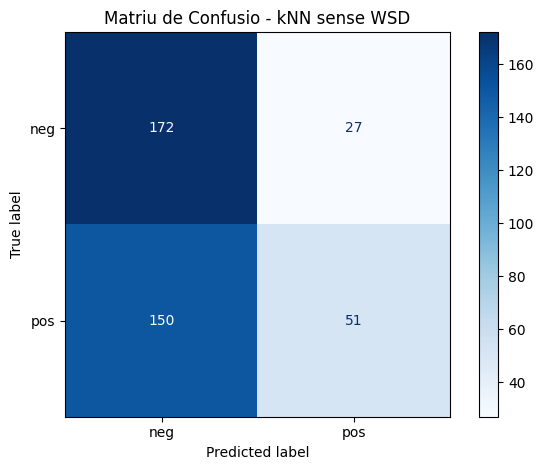

In [29]:
# Baseline: kNN sense WSD (mateix esquema de vectorització i grid)
pipe_knn_no_wsd = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn_no_wsd = {
    'vect__max_features': [5000, 12000, 15000, 20000],
    'knn__n_neighbors': [3, 5, 7, 11]
}

grid_knn_no_wsd = GridSearchCV(
    estimator=pipe_knn_no_wsd,
    param_grid=param_grid_knn_no_wsd,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn_no_wsd.fit(X_train, y_train)
y_pred_knn_no_wsd = grid_knn_no_wsd.best_estimator_.predict(X_test)

acc_no_wsd = accuracy_score(y_test, y_pred_knn_no_wsd)
f1_no_wsd = f1_score(y_test, y_pred_knn_no_wsd, pos_label='pos', zero_division=0)

acc_wsd = accuracy_score(y_test_wsd, y_pred_wsd_knn)
f1_wsd = f1_score(y_test_wsd, y_pred_wsd_knn, pos_label='pos', zero_division=0)


print('Millors params kNN sense WSD:', grid_knn_no_wsd.best_params_)
print(f'Best CV f1_macro (sense WSD): {grid_knn_no_wsd.best_score_:.4f}')

df_compare_knn = pd.DataFrame([
    {
        'Model': 'kNN sense WSD',
        'Accuracy': f'{acc_no_wsd:.4f}',
        'F1-pos': f'{f1_no_wsd:.4f}'
    }
])

print('\nResultats de test:')
print(df_compare_knn.to_string(index=False))

# Matrius de confusio per comparar visualment
cm_no_wsd = confusion_matrix(y_test, y_pred_knn_no_wsd, labels=['neg', 'pos'])
disp_no_wsd = ConfusionMatrixDisplay(confusion_matrix=cm_no_wsd, display_labels=['neg', 'pos'])
plt.figure(figsize=(6, 5))
disp_no_wsd.plot(cmap='Blues')
plt.title('Matriu de Confusio - kNN sense WSD')
plt.tight_layout()
plt.show()



Per comparar l'impacte del WSD, també s'ha entrenat un kNN sense enriquiment semàntic. 
Els millors hiperparàmetres obtinguts mitjançant validació creuada han estat `n_neighbors=3` 
i `max_features=12000`, amb un F1-macro de 0.54 en validació.

Els resultats sobre el conjunt de test mostren una accuracy del 55.75% i un F1 de la 
classe *pos* de 0.37, resultats fins i tot inferiors als del kNN amb WSD. La matriu de 
confusió reflecteix el mateix patró de biaix cap a la classe negativa: el model encerta 
172 de les 199 mostres negatives, però només classifica correctament 51 de les 201 mostres 
positives, errant en 150 casos. En total, comet 177 errors sobre 400 mostres, una taxa 
d'error del 44.25%.

Comparant els dos models, el kNN amb WSD obté uns resultats lleugerament superiors 
(accuracy 58.25% vs 55.75%, F1-pos 0.43 vs 0.37), cosa que suggereix que l'enriquiment 
semàntic amb Lesk aporta una petita millora. Tot i això, ambdós models presenten un 
rendiment molt modest i un biaix notable cap a la classe negativa, molt per sota dels 
resultats obtinguts amb SVM, Regressió Logística o XGBoost a la primera part de la pràctica.

Per observar si el WSD pot millorar realment el rendiment en la detecció de sentiments, 
s'han comparat els errors comesos per cadascun dels models, i s'ha observat el següent. 
Cal tenir en compte que, com s'ha comentat, és possible que el model escollit (kNN) 
no sigui el més adequat per a aquesta tasca.

In [32]:
# Mostrar frases mal classificades de tots dos models
print("="*80)
print("FRASES MAL CLASSIFICADES - kNN sense WSD")
print("="*80)

# kNN sense WSD
y_test_arr = np.array(y_test)
y_pred_knn_no_wsd_arr = np.array(y_pred_knn_no_wsd)
errors_mask_no_wsd = y_test_arr != y_pred_knn_no_wsd_arr
error_indices_no_wsd = np.where(errors_mask_no_wsd)[0]

print(f"\nTotal errors: {len(error_indices_no_wsd)}/{len(y_test_arr)}")
print(f"Error rate: {len(error_indices_no_wsd)/len(y_test_arr):.4%}\n")

for i, idx in enumerate(error_indices_no_wsd, 1):
    real = y_test_arr[idx]
    predicted = y_pred_knn_no_wsd_arr[idx]
    text = X_test[idx]
    text_wsd = X_test_wsd[idx]
    print(f"{i}. Real: {real:3s} | Predicted: {predicted:3s}")
    print(f"   Original: {text}")
    print(f"   WSD:      {text_wsd}\n")

print("\n" + "="*80)
print("FRASES MAL CLASSIFICADES - kNN amb WSD")
print("="*80)

# kNN amb WSD
y_test_wsd_arr = np.array(y_test_wsd)
y_pred_wsd_knn_arr = np.array(y_pred_wsd_knn)
errors_mask_wsd = y_test_wsd_arr != y_pred_wsd_knn_arr
error_indices_wsd = np.where(errors_mask_wsd)[0]

print(f"\nTotal errors: {len(error_indices_wsd)}/{len(y_test_wsd_arr)}")
print(f"Error rate: {len(error_indices_wsd)/len(y_test_wsd_arr):.4%}\n")

for i, idx in enumerate(error_indices_wsd, 1):
    real = y_test_wsd_arr[idx]
    predicted = y_pred_wsd_knn_arr[idx]
    text_original = X_test[idx]
    text_wsd = X_test_wsd[idx]
    print(f"{i}. Real: {real:3s} | Predicted: {predicted:3s}")
    print(f"   Original: {text_original}")
    print(f"   WSD:      {text_wsd}\n")


FRASES MAL CLASSIFICADES - kNN sense WSD

Total errors: 177/400
Error rate: 44.2500%

1. Real: pos | Predicted: neg
   Original: verdict spine chilling drama horror maestro stephen king featuring outstanding oscar winning performance kathy bates geez french saunders field day set work parodying sorry non british reader may not familiar french saunders apology pair british comedienne jennifer saunders later went become edina monsoon absolutely fabulous series film spoof year back including alien exorcist misery needless say amidst chucklesome impersonation kathy bates resemblance quite uncanny dawn french got pretty nasty sledgehammer reach jennifer saunder leg despite lingering memory sketch although seen film couple time hobbling scene no less disturbing still left screaming telly revulsion may memorable scene certainly not worth watching stephen king whose film tv adaptation tend vary quality strike gold simple yet strikingly compelling tale nicely crafted psychological horror effort


## Conclusions: KNN amb WSD vs. sense WSD

### Patrons d'error compartits

El més destacable és que **ambdós models fallen exactament pels mateixos motius i en les mateixes ressenyes** (#1 *Misery*, #12 *Devil's Advocate*, #32 *Anaconda*, etc.). Això suggereix que els errors no provenen de la resolució de la polisèmia, sinó de limitacions més estructurals del classificador.

Els tres grans punts febles compartits són:

- **Vocabulari negatiu en context positiu**: paraules com "nauseating" o "nasty" usades per elogiar enganyen els dos models igualment.
- **Ressenyes llargues i matisades**: quan una crítica positiva inclou objeccions parcials, cap dels dos models aconsegueix captar el to global.
- **Ironia i humor**: un to juganere en ressenyes negatives (#32 *Anaconda*) es confon amb entusiasme en ambdós casos.

### L'impacte del WSD: mínim o nul

La incorporació del WSD **no ha millorat la capacitat del model per gestionar cap d'aquests reptes**. Això té sentit: la desambiguació lèxica ajuda a distingir, per exemple, "bank" (riu vs. institució financera), però no resol el problema de fons, que és la **comprensió del context pragmàtic i del to global** d'un text.

En altres paraules, el WSD és una eina per a la polisèmia lèxica, però els errors d'aquest classificador són majoritàriament errors de **pragmàtica i de sentiment composicional**, que queden fora del seu abast.

### Limitació de fons: KNN com a model

Més enllà del WSD, els resultats apunten a una limitació inherent de KNN per a aquesta tasca: el model es basa en similitud superficial entre vectors, sense mecanismes per capturar la negació, la ironia o l'estructura argumentativa d'una ressenya. Un model que tingués en compte la **polaritat contextual** o l'**estructura discursiva** hauria de cometre errors molt menys sistemàtics que aquests.

**El problema del WSD (Word Sense Disambiguation)**

Cal notar que totes les ressenyes inclouen anotació semàntica (*sense_*). Paradoxalment, aquesta informació addicional no sembla ajudar prou: termes com "sense_horror_n_01" vs "sense_horror_n_02" o "sense_good_a_01" apareixen en contextos molt variats i el model no aprofita adequadament la distinció entre, per exemple, *horror* com a gènere cinematogràfic i *horror* com a emoció.

En resum, els errors reflecteixen la dificultat clàssica de l'anàlisi de sentiments: el context global i la ironia superen la capacitat dels models basats en vocabulari local.